# BTC Trade Analysis

This project analyzes Bitcoin trading activity using trade-level data from Binance.

The analysis includes:

- price dynamics
- trading volume
- trade size distribution

Tools used: Python, pandas, matplotlib, Jupyter Notebook.

In [1]:
import pandas as pd

In [6]:
df = pd.read_csv("BTCUSDT-trades-2026-03-10.csv")

In [7]:
df.head()

,6085646591,68432.16000000,0.00007000,4.79025120,1773100800116018,False,True
0,6085646592,68432.15,0.00016,10.949144,1773100800125267,True,True
1,6085646593,68432.15,0.00008,5.474572,1773100800125267,True,True
2,6085646594,68432.15,0.00008,5.474572,1773100800125267,True,True
3,6085646595,68432.15,0.00008,5.474572,1773100800125267,True,True
4,6085646596,68432.15,0.00008,5.474572,1773100800125267,True,True


In [8]:
df.shape

(5176063, 7)

In [9]:
df.columns


Index(['6085646591', '68432.16000000', '0.00007000', '4.79025120',
       '1773100800116018', 'False', 'True'],
      dtype='object')

In [10]:
df = pd.read_csv("BTCUSDT-trades-2026-03-10.csv", header=None)


In [11]:
df.head()

,0,1,2,3,4,5,6
0,6085646591,68432.16,0.00007,4.790251,1773100800116018,False,True
1,6085646592,68432.15,0.00016,10.949144,1773100800125267,True,True
2,6085646593,68432.15,0.00008,5.474572,1773100800125267,True,True
3,6085646594,68432.15,0.00008,5.474572,1773100800125267,True,True
4,6085646595,68432.15,0.00008,5.474572,1773100800125267,True,True


In [12]:
df.columns = [
    "trade_id",
    "price",
    "quantity",
    "quote_qty",
    "time",
    "is_buyer_maker",
    "is_best_match"
]


In [13]:
df.head()


,trade_id,price,quantity,quote_qty,time,is_buyer_maker,is_best_match
0,6085646591,68432.16,0.00007,4.790251,1773100800116018,False,True
1,6085646592,68432.15,0.00016,10.949144,1773100800125267,True,True
2,6085646593,68432.15,0.00008,5.474572,1773100800125267,True,True
3,6085646594,68432.15,0.00008,5.474572,1773100800125267,True,True
4,6085646595,68432.15,0.00008,5.474572,1773100800125267,True,True


In [16]:
df["time"] = pd.to_datetime(df["time"], unit="us")


In [17]:
df.head()


,trade_id,price,quantity,quote_qty,time,is_buyer_maker,is_best_match
0,6085646591,68432.16,0.00007,4.790251,2026-03-10 00:00:00.116018,False,True
1,6085646592,68432.15,0.00016,10.949144,2026-03-10 00:00:00.125267,True,True
2,6085646593,68432.15,0.00008,5.474572,2026-03-10 00:00:00.125267,True,True
3,6085646594,68432.15,0.00008,5.474572,2026-03-10 00:00:00.125267,True,True
4,6085646595,68432.15,0.00008,5.474572,2026-03-10 00:00:00.125267,True,True


In [18]:
df["minute"] = df["time"].dt.floor("min")

## Distribution of Trade Sizes

This chart shows the average BTC price aggregated by minute.

The visualization helps identify intraday price movements and periods of increased volatility during the trading day.

In [19]:
price_by_minute = df.groupby("minute")["price"].mean()

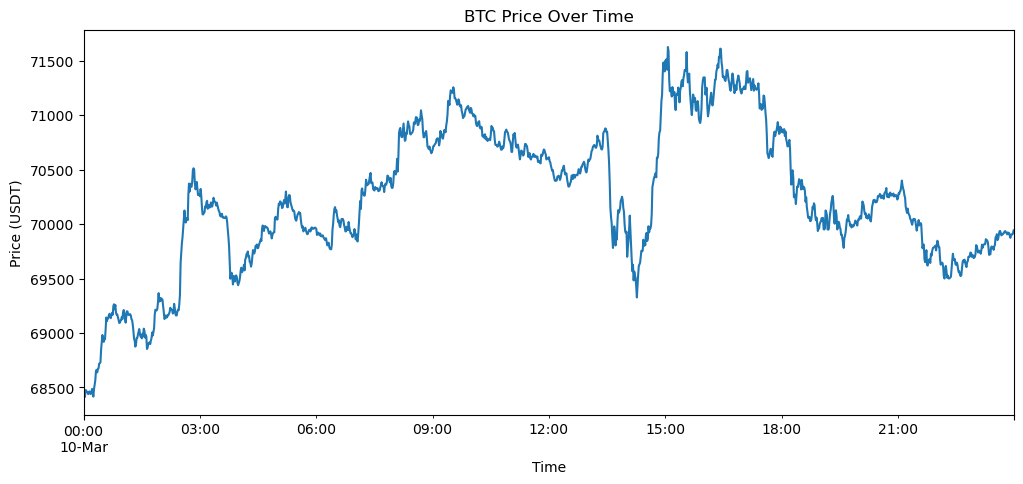

In [20]:
import matplotlib.pyplot as plt

price_by_minute.plot(figsize=(12,5))

plt.title("BTC Price Over Time")
plt.xlabel("Time")
plt.ylabel("Price (USDT)")
plt.show()


In [21]:
volume_by_minute = df.groupby("minute")["quote_qty"].sum()


## BTC Trading Volume Over Time

This chart shows the trading volume aggregated by minute.

Volume spikes indicate periods of increased trading activity and often coincide with significant price movements.

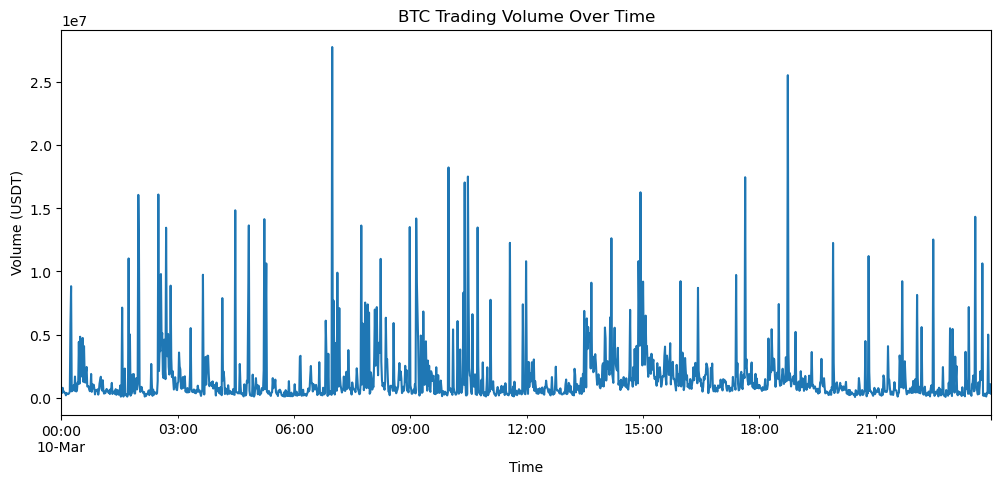

In [22]:
import matplotlib.pyplot as plt

volume_by_minute.plot(figsize=(12,5))

plt.title("BTC Trading Volume Over Time")
plt.xlabel("Time")
plt.ylabel("Volume (USDT)")
plt.show()


## BTC Trading Volume Over Time

This chart shows the trading volume aggregated by minute.

Volume spikes indicate periods of increased trading activity and often coincide with significant price movements.

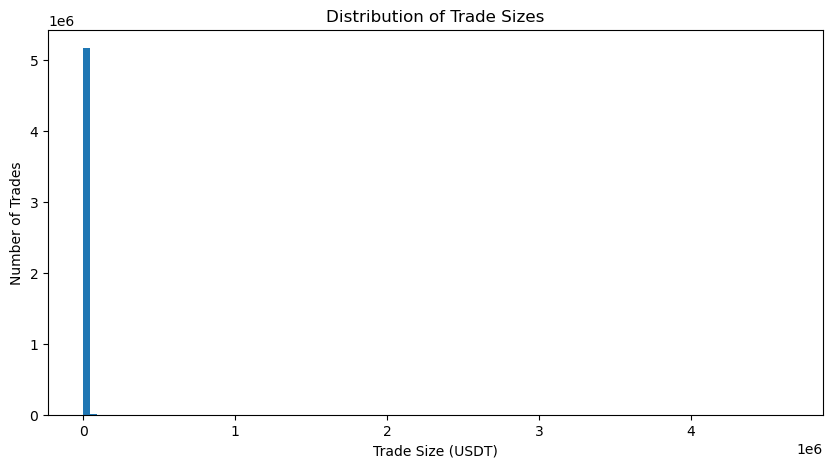

In [23]:
plt.figure(figsize=(10,5))

plt.hist(df["quote_qty"], bins=100)

plt.title("Distribution of Trade Sizes")
plt.xlabel("Trade Size (USDT)")
plt.ylabel("Number of Trades")

plt.show()


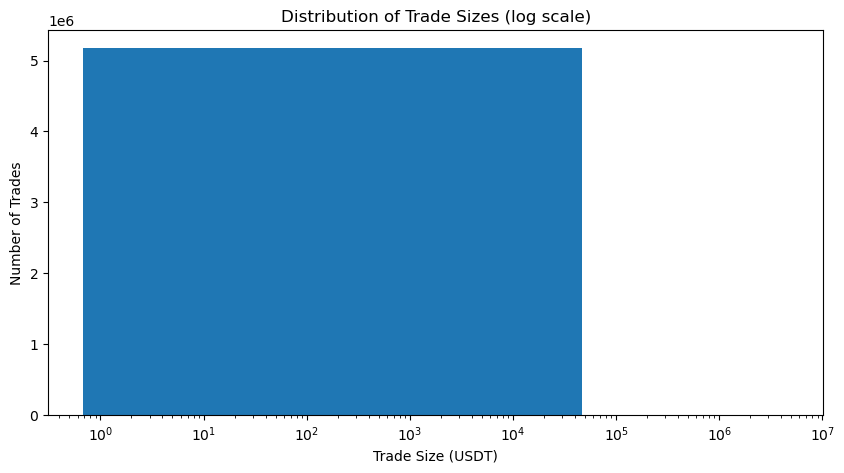

In [24]:
plt.figure(figsize=(10,5))
plt.hist(df["quote_qty"], bins=100)
plt.xscale("log")  # лог-шкала по оси X
plt.title("Distribution of Trade Sizes (log scale)")
plt.xlabel("Trade Size (USDT)")
plt.ylabel("Number of Trades")
plt.show()


In [25]:
df["quote_qty"].describe()


count    5.176064e+06
mean     4.429091e+02
std      5.712300e+03
min      6.839999e-01
25%      5.602882e+00
50%      5.659198e+00
75%      1.116123e+01
max      4.640131e+06
Name: quote_qty, dtype: float64

In [26]:
df["quote_qty"].nlargest(10)

268885     4.640131e+06
312004     2.889539e+06
312483     1.786411e+06
312494     1.385200e+06
1823026    1.276956e+06
1495091    1.245344e+06
1891214    1.242870e+06
1677515    1.241867e+06
1231093    1.227144e+06
2038627    1.198818e+06
Name: quote_qty, dtype: float64

In [27]:
(df["quote_qty"] > 10000).sum()

np.int64(52763)

In [28]:
(df["quote_qty"] > 10000).mean()

np.float64(0.010193652937830753)

## Key Metrics

Summary statistics of BTC trading activity:

- Total number of trades: **5,176,064**
- Median trade size: **~5.66 USDT**
- Average trade size: **~443 USDT**
- Largest trade observed: **~4.64M USDT**
- Share of trades larger than 10,000 USDT: **~1%**

## Conclusions

The dataset contains more than 5 million BTC trades.

Most trades are small, with a median trade size of around 5.6 USDT.

Only about 1% of trades exceed 10,000 USDT, indicating that the majority of market activity comes from smaller traders, while large participants occasionally execute very large transactions.

Volume spikes often coincide with price movements, suggesting increased trading activity during periods of higher volatility.
